# Weather Classification Model

Classify `condition_text` (เช่น Clear / Cloudy / Rain / Thunder ...) จากตัวแปรอากาศอื่น ๆ

## 1. Imports

In [19]:
# หน้าที่ของผม : Weather Classification (condition_text)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RNG = 42

## 2. Bridge สร้าง df_model โดยมีคอลัมน์วันที่รวมอยู่

In [20]:
try:
    df_model = bangkok_df.copy()
    print("Loaded bangkok_df from memory (teammate's notebook)")
except NameError:
    print("bangkok_df not found — loading from Cleaned_Weather_Data.csv (standalone mode)")
    df_model = pd.read_csv("Cleaned_Weather_Data.csv")

    # สร้าง feature columns ที่เพื่อนทำไว้ขึ้นมาใหม่ เพื่อให้ชื่อตรงกัน
    def _season(m):
        if m in [11, 12, 1, 2]: return "Cool"
        if m in [3, 4, 5]:      return "Hot"
        return "Rainy"
    df_model["season"]   = df_model["month"].apply(_season)
    df_model["pm_lag"]       = df_model["air_quality_PM2.5"].shift(1)
    df_model["wind_lag"]     = df_model["wind_kph"].shift(1)
    df_model["uv_lag"]       = df_model["uv_index"].shift(1)
    df_model["humidity_lag"] = df_model["humidity"].shift(1)
    df_model["cloud_lag"]    = df_model["cloud"].shift(1)
    df_model["Humidity_over_Cloud"]      = df_model["humidity"] / df_model["cloud"]
    df_model["Humidity_over_Temp"]       = df_model["humidity"] / df_model["temperature_celsius"]
    df_model["Humidity_over_Visibility"] = df_model["humidity"] / df_model["visibility_km"]
    df_model["Gust_over_Wind"]           = df_model["gust_kph"] / df_model["wind_kph"]
    df_model["is_day"] = df_model["hour"].apply(lambda x: 1 if 6 <= x <= 18 else 0)

# แปลงเป็น datetime ให้ถูกต้อง + ลบแถวที่วันที่ซ้ำกันออก
df_model["date"] = pd.to_datetime(df_model[["year", "month", "day"]])
df_model = (df_model
            .sort_values("date")
            .drop_duplicates("date", keep="last")
            .reset_index(drop=True))

# อัตราส่วนที่เพื่อนสร้างไว้อาจได้ inf ถ้าตัวหารเป็น 0 ต้องจัดการด้วย
df_model = df_model.replace([np.inf, -np.inf], np.nan)
num_cols = df_model.select_dtypes(include=[np.number]).columns
df_model[num_cols] = df_model[num_cols].fillna(df_model[num_cols].median())

print(f"Rows: {len(df_model)}   |   Date range: {df_model['date'].min().date()} → {df_model['date'].max().date()}")
df_model[["date", "temperature_celsius", "humidity", "wind_kph", "precip_mm", "condition_text"]].tail()

bangkok_df not found — loading from Cleaned_Weather_Data.csv (standalone mode)
Rows: 704   |   Date range: 2024-05-16 → 2026-04-24


,date,temperature_celsius,humidity,wind_kph,precip_mm,condition_text
699,2026-04-20,37.1,45,19.1,0.0,Clear
700,2026-04-21,36.2,45,18.0,0.0,Cloudy
701,2026-04-22,37.2,42,20.5,0.0,Cloudy
702,2026-04-23,36.2,53,23.4,0.0,Cloudy
703,2026-04-24,35.4,56,20.2,0.0,Cloudy


## 3. Feature Engineering สำหรับ Classification

เพิ่ม lag(1, 2, 3, 7) + rolling(3, 7) ของตัวแปรอากาศหลัก ๆ + วันของปีแบบวนซ้ำ (sin/cos)

In [21]:
LAG_COLS = ["temperature_celsius", "humidity", "wind_kph", "precip_mm",
            "pressure_mb", "cloud", "uv_index"]


def add_model_features(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()
    d["dayofyear"] = d["date"].dt.dayofyear
    d["doy_sin"]   = np.sin(2 * np.pi * d["dayofyear"] / 365.25)
    d["doy_cos"]   = np.cos(2 * np.pi * d["dayofyear"] / 365.25)
    for c in LAG_COLS:
        for lag in [1, 2, 3, 7]:
            d[f"{c}_lag{lag}"] = d[c].shift(lag)
        d[f"{c}_roll3"] = d[c].shift(1).rolling(3).mean()
        d[f"{c}_roll7"] = d[c].shift(1).rolling(7).mean()
    return d


feat = add_model_features(df_model)
print("After feature engineering:", feat.shape)

After feature engineering: (704, 82)


## 4. Time-based Train / Test Split

ใช้เวลาเป็นตัวกำหนด — Test = 11–24 เม.ย. 2026 (14 วันล่าสุด)

In [22]:
TEST_START = pd.Timestamp("2026-04-11")
TEST_END   = pd.Timestamp("2026-04-24")

lag_cols = [c for c in feat.columns if "_lag" in c or "_roll" in c]
data = feat.dropna(subset=lag_cols).reset_index(drop=True)

train = data[data["date"] <  TEST_START].copy()
test  = data[(data["date"] >= TEST_START) & (data["date"] <= TEST_END)].copy()
print(f"Train: {len(train)} rows   ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Test : {len(test)} rows   ({test['date'].min().date()} → {test['date'].max().date()})")

# ตัด target ของ task อื่น (PM 2.5 regression) + คอลัมน์ที่จะเป็น leakage ออก
LEAK = {
    "date", "condition_text", "condition_name", "moon_phase",
    "air_quality_Carbon_Monoxide", "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide", "air_quality_Sulphur_dioxide",
    "air_quality_PM2.5", "air_quality_PM10",
    "air_quality_us-epa-index", "air_quality_gb-defra-index",
    "moon_illumination",
    # อัตราส่วนของเพื่อนใช้ค่า ณ เวลา t เลย → leakage ต้องเอาออก
    "Humidity_over_Cloud", "Humidity_over_Temp",
    "Humidity_over_Visibility", "Gust_over_Wind",
}
FEATURES = [c for c in data.columns if c not in LEAK and data[c].dtype != "object"]
print(f"\n{len(FEATURES)} features used for classification.")

Train: 683 rows   (2024-05-24 → 2026-04-10)
Test : 14 rows   (2026-04-11 → 2026-04-24)

65 features used for classification.


## 5. Classification Model : `condition_text`

ใช้ RandomForestClassifier + class_weight="balanced" เพื่อจัดการกับคลาสที่ไม่สมดุล

In [23]:
le = LabelEncoder()
data["condition_y"]  = le.fit_transform(data["condition_text"])
train["condition_y"] = le.transform(train["condition_text"])
test["condition_y"]  = le.transform(test["condition_text"])

clf = RandomForestClassifier(n_estimators=400, random_state=RNG, n_jobs=-1,
                             class_weight="balanced")
clf.fit(train[FEATURES], train["condition_y"])

# ทดสอบกับข้อมูล 14 วัน (11–24 เม.ย.)
pred_test = clf.predict(test[FEATURES])
print("=== 14-day window (Apr 11–24) ===")
print(f"Accuracy: {accuracy_score(test['condition_y'], pred_test):.3f}")
print(f"Macro F1: {f1_score(test['condition_y'], pred_test, average='macro'):.3f}")

# ทดสอบย้อนหลัง 30 วัน เพื่อเช็กว่าโมเดลยังใช้ได้อยู่ (sanity check)
holdout = train.tail(30)
pred_30 = clf.predict(holdout[FEATURES])
print("\n=== 30-day backtest (sanity) ===")
print(f"Accuracy: {accuracy_score(holdout['condition_y'], pred_30):.3f}")
print(f"Macro F1: {f1_score(holdout['condition_y'], pred_30, average='macro'):.3f}")
print(classification_report(holdout['condition_y'], pred_30,
                            labels=list(range(len(le.classes_))),
                            target_names=le.classes_, zero_division=0))

=== 14-day window (Apr 11–24) ===
Accuracy: 0.929
Macro F1: 0.918

=== 30-day backtest (sanity) ===
Accuracy: 1.000
Macro F1: 1.000
              precision    recall  f1-score   support

       Clear       1.00      1.00      1.00        18
      Cloudy       1.00      1.00      1.00        10
     Drizzle       0.00      0.00      0.00         0
        Rain       0.00      0.00      0.00         0
     Thunder       1.00      1.00      1.00         2

    accuracy                           1.00        30
   macro avg       0.60      0.60      0.60        30
weighted avg       1.00      1.00      1.00        30



## 6. Predicted vs Actual (Apr 11 – 24)

In [24]:
cmp = test[["date", "condition_text"]].copy()
cmp["condition_pred"]   = le.inverse_transform(pred_test)
cmp = cmp.rename(columns={"condition_text": "condition_actual"})
cmp["correct"] = cmp["condition_pred"] == cmp["condition_actual"]

cls_acc = cmp["correct"].mean()
n = len(cmp)
print(f"condition_text accuracy = {cls_acc:.2f}  ({int(round(cls_acc * n))}/{n} days)\n")
cmp

condition_text accuracy = 0.93  (13/14 days)



,date,condition_actual,condition_pred,correct
683,2026-04-11,Clear,Clear,True
684,2026-04-12,Clear,Clear,True
685,2026-04-13,Clear,Clear,True
686,2026-04-14,Clear,Clear,True
687,2026-04-15,Clear,Clear,True
688,2026-04-16,Clear,Clear,True
689,2026-04-17,Cloudy,Cloudy,True
690,2026-04-18,Clear,Clear,True
691,2026-04-19,Clear,Clear,True
692,2026-04-20,Clear,Clear,True


## 7. Visualizations

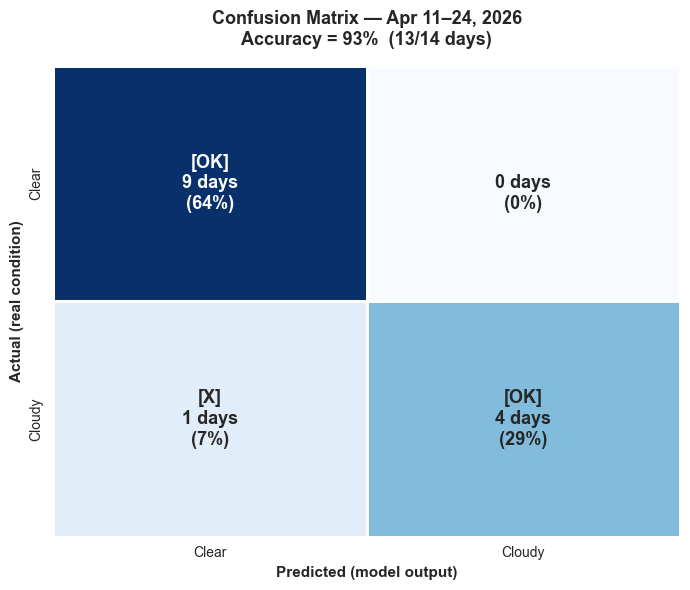

In [25]:
# Confusion Matrix — show count + percentage + check/cross marks
labels_present = np.unique(np.concatenate([test["condition_y"].values, pred_test]))
cm = confusion_matrix(test["condition_y"], pred_test, labels=labels_present)
label_names = le.inverse_transform(labels_present)
n_total = cm.sum()

# Build annotation : count + % + correct/wrong mark in each cell
annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        pct = count / n_total * 100
        if i == j:
            mark = "[OK]"
        elif count > 0:
            mark = "[X]"
        else:
            mark = ""
        annot[i, j] = f"{mark}\n{count} days\n({pct:.0f}%)"

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names,
            cbar=False, linewidths=2, linecolor="white",
            annot_kws={"size": 13, "weight": "bold"}, ax=ax)

acc = np.trace(cm) / n_total
ax.set_title(f"Confusion Matrix — Apr 11–24, 2026\nAccuracy = {acc:.0%}  ({np.trace(cm)}/{n_total} days)",
             fontweight="bold", fontsize=13, pad=15)
ax.set_xlabel("Predicted (model output)", fontsize=11, fontweight="bold")
ax.set_ylabel("Actual (real condition)", fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

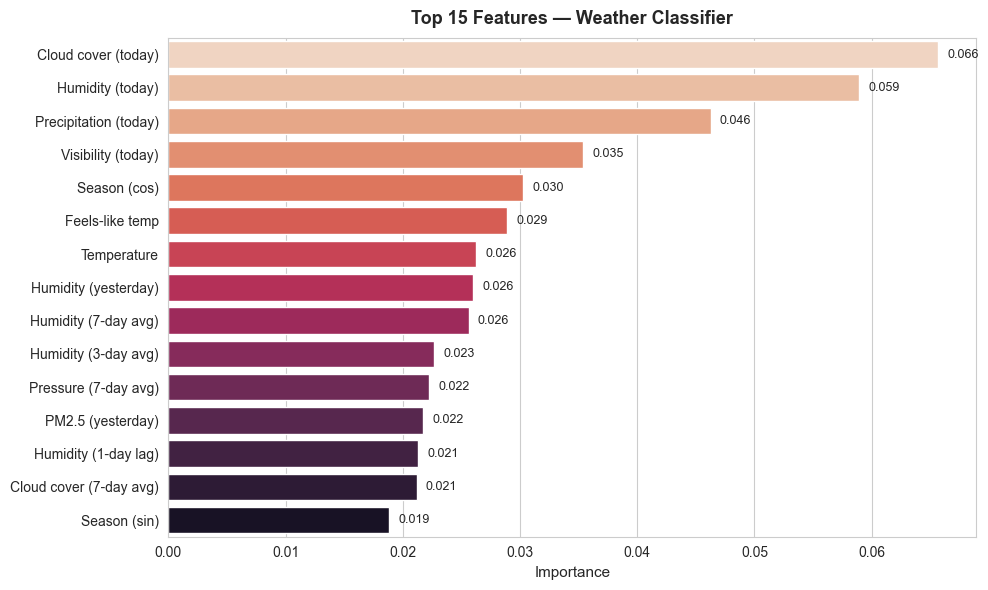

In [26]:
# Top features ของ classifier — แสดงชื่อแบบอ่านเข้าใจง่าย
FEATURE_NAMES_EN = {
    "cloud":              "Cloud cover (today)",
    "humidity":           "Humidity (today)",
    "precip_mm":          "Precipitation (today)",
    "visibility_km":      "Visibility (today)",
    "feels_like_celsius": "Feels-like temp",
    "temperature_celsius": "Temperature",
    "pressure_mb":        "Pressure",
    "uv_index":           "UV index",
    "wind_kph":           "Wind speed",
    "gust_kph":           "Wind gust",
    "doy_sin":            "Season (sin)",
    "doy_cos":            "Season (cos)",
    "dayofyear":          "Day of year",
    "month":              "Month",
    "hour":               "Hour",
    "is_day":             "Is daytime",
    "humidity_lag":       "Humidity (yesterday)",
    "cloud_lag":          "Cloud cover (yesterday)",
    "wind_lag":           "Wind speed (yesterday)",
    "uv_lag":             "UV (yesterday)",
    "pm_lag":             "PM2.5 (yesterday)",
}

def pretty_name(c: str) -> str:
    """Convert technical feature name to human-readable label."""
    if c in FEATURE_NAMES_EN:
        return FEATURE_NAMES_EN[c]
    # Handle auto-generated patterns: humidity_lag1, cloud_roll3, pressure_mb_lag7, ...
    for base, label in FEATURE_NAMES_EN.items():
        clean_label = label.split(" (")[0]  # drop suffix like " (today)"
        if c.startswith(base + "_lag"):
            n = c.replace(base + "_lag", "")
            return f"{clean_label} ({n}-day lag)"
        if c.startswith(base + "_roll"):
            n = c.replace(base + "_roll", "")
            return f"{clean_label} ({n}-day avg)"
    return c  # fallback

imp = pd.Series(clf.feature_importances_, index=FEATURES) \
        .sort_values(ascending=False).head(15)
imp_pretty = imp.copy()
imp_pretty.index = [pretty_name(c) for c in imp.index]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=imp_pretty.values, y=imp_pretty.index, palette="rocket_r")
for i, v in enumerate(imp_pretty.values):
    ax.text(v + 0.0008, i, f"{v:.3f}", va="center", fontsize=9)
plt.title("Top 15 Features — Weather Classifier",
          fontweight="bold", fontsize=13, pad=10)
plt.xlabel("Importance", fontsize=11)
plt.ylabel("")
plt.tight_layout(); plt.show()

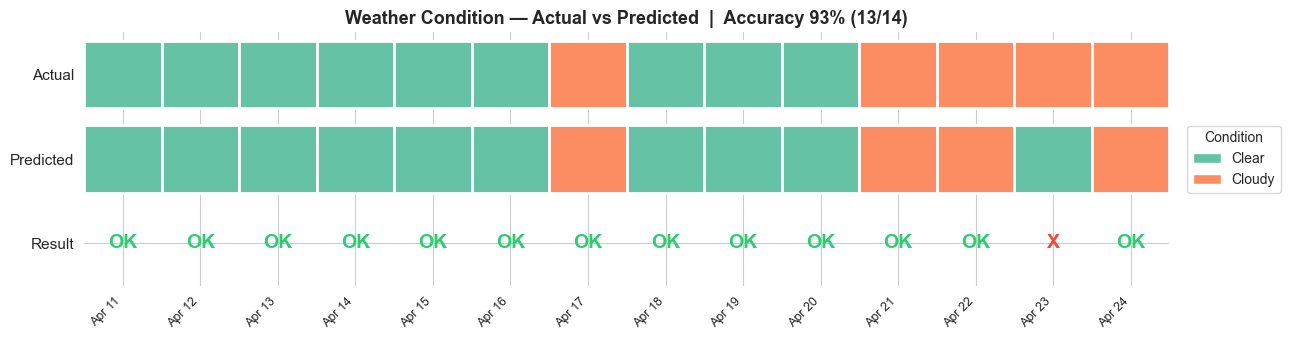

In [ ]:
# Timeline แบบแถบสี 
# มอง 3 แถว : Actual (จริง), Predicted (ทาย), Result (ถูก/ผิด)
from matplotlib.patches import Patch

all_classes = sorted(set(cmp['condition_actual']) | set(cmp['condition_pred']))
palette = dict(zip(all_classes, sns.color_palette('Set2', len(all_classes))))

fig, ax = plt.subplots(figsize=(13, 3.5))
n = len(cmp)

for i, row in cmp.reset_index(drop=True).iterrows():
    # Top row : Actual
    ax.barh(y=2, width=1, left=i, color=palette[row['condition_actual']],
            edgecolor='white', linewidth=2)
    # Middle row : Predicted
    ax.barh(y=1, width=1, left=i, color=palette[row['condition_pred']],
            edgecolor='white', linewidth=2)
    # Bottom row : correct / wrong  (use plain ASCII for matplotlib)
    correct = row['condition_actual'] == row['condition_pred']
    ax.text(i + 0.5, 0, 'OK' if correct else 'X',
            ha='center', va='center', fontsize=14,
            color='#2ecc71' if correct else '#e74c3c', fontweight='bold')

# Y-axis labels
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['Result', 'Predicted', 'Actual'], fontsize=11)
ax.set_ylim(-0.5, 2.5)

# X-axis labels = dates
ax.set_xticks(np.arange(n) + 0.5)
ax.set_xticklabels([d.strftime('%b %d') for d in cmp['date']],
                   rotation=45, ha='right', fontsize=9)
ax.set_xlim(0, n)

# Color legend
legend_elems = [Patch(facecolor=palette[c], label=c) for c in all_classes]
ax.legend(handles=legend_elems, loc='center left',
          bbox_to_anchor=(1.01, 0.5), title='Condition')

acc = cmp['correct'].mean()
ax.set_title(f"Weather Condition — Actual vs Predicted  |  Accuracy {acc:.0%} ({cmp['correct'].sum()}/{n})",
             fontweight='bold', fontsize=13)
ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
ax.tick_params(left=False, bottom=False)
plt.tight_layout(); plt.show()